# GMM Expectation-Maximization Covariance Clustering

Gaussian Mixture Models (GMM) model data distributions using linear combinations of multivariate Gaussian probability density functions. While K-Means assumes spherical clusters, GMM handles ellipsoidal clusters via parameterized covariance matrices. This notebook generates overlapping coordinate clusters (500 samples), fits GMM using expectation-maximization (EM), and visualizes the covariance probability ellipses using Matplotlib patches.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.mixture import GaussianMixture

# Generate synthetic 2D coordinate clusters (500 samples, 3 centers with varying covariances)
np.random.seed(172)
n_samples = 500

# Gaussian components parameters
means = [[1.5, 1.5], [-2.0, 0.0], [1.0, -2.0]]
covs = [
    [[0.4, 0.1], [0.1, 0.2]], # Slightly tilted
    [[0.6, -0.3], [-0.3, 0.5]], # Tilted diagonally
    [[0.2, 0.0], [0.0, 0.8]]  # Elongated vertically
]

X_list = []
for mean, cov in zip(means, covs):
    X_list.append(np.random.multivariate_normal(mean, cov, n_samples // 3))

X = np.vstack(X_list)

df_gmm = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df_gmm.head(10)



,Feature_1,Feature_2
0,0.971341,0.769138
1,0.888381,1.363663
2,2.353422,1.346086
3,1.932462,0.971156
4,0.675768,1.565893
5,1.364520,1.064290
6,1.322260,1.198932
7,0.979015,1.302752
8,1.003571,2.537960
9,1.243536,1.270806


## GMM Pipeline Fitting

We fit a 3-component Gaussian Mixture Model with a "full" covariance constraint to extract the model means and covariance matrices.



In [2]:
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X)

# Predict cluster memberships
labels = gmm.predict(X)

print("Estimated Cluster Means:\n", gmm.means_)
print("\nEstimated Covariances:\n", gmm.covariances_)



Estimated Cluster Means:
 [[-2.00792895 -0.00813403]
 [ 0.99313163 -2.10077918]
 [ 1.44194363  1.45242564]]

Estimated Covariances:
 [[[ 0.5710714  -0.30080933]
  [-0.30080933  0.52107533]]

 [[ 0.20320251 -0.01183891]
  [-0.01183891  0.79280988]]

 [[ 0.30697866  0.04763962]
  [ 0.04763962  0.20024879]]]


## GMM Covariance Probability Ellipses Visualization

We draw the data points colored by cluster membership and construct 1-standard deviation covariance ellipses around the GMM means using Matplotlib patches.



<cell>:37: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



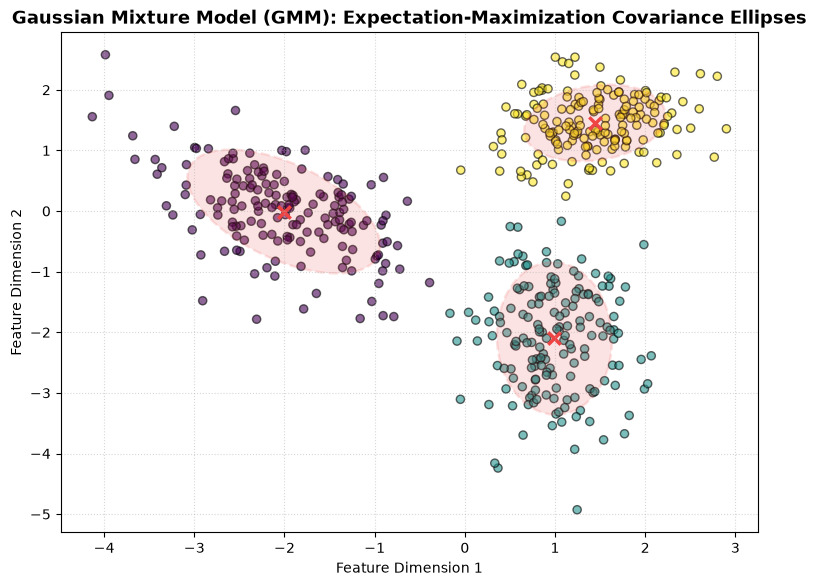

In [3]:
fig, ax = plt.subplots(figsize=(9, 6.5))

# Scatter data points
ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k', s=35, alpha=0.6)

# Draw covariance ellipses
for i in range(3):
    mean = gmm.means_[i]
    cov = gmm.covariances_[i]
    
    # Calculate eigenvalues and eigenvectors for ellipse rotation
    v, w = np.linalg.eigh(cov)
    u = w[0] / np.linalg.norm(w[0])
    angle = np.arctan2(u[1], u[0])
    angle = 180 * angle / np.pi # Convert to degrees
    
    # Standard deviation width/height
    v = 2.0 * np.sqrt(2.0) * np.sqrt(v)
    
    # Draw transparent ellipse patches representing 2 standard deviations
    ellipse = patches.Ellipse(
        mean, v[0], v[1], 
        angle=180 + angle, 
        color='#EF4444', 
        alpha=0.15,
        linewidth=1.8,
        linestyle='--'
    )
    
    ax.add_patch(ellipse)
    ax.scatter(mean[0], mean[1], c='#EF4444', marker='x', s=80, linewidths=2.5)

ax.set_title('Gaussian Mixture Model (GMM): Expectation-Maximization Covariance Ellipses', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Dimension 1')
ax.set_ylabel('Feature Dimension 2')
ax.grid(True, linestyle=':', alpha=0.5)
plt.show()
